In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
from pathlib import Path

import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.codon import CodonDataset
from peint.models.modules.peint_module import PEINTModule
from peint.models.nets.peint import PEINT, ESMCodonEncoder, PEINTGenerator

from evo.sequence import get_mutant
from evo.dms import get_site_by_site_consensus
from evo.dataset import ComplexCherriesDataset
from evo.tokenization import CodonVocab
from evo.tensor import collate_list_of_dicts, collate_tensors
from evo.antibody import create_region_masks

from Bio.Seq import Seq
from abnumber import Chain

from tqdm import tqdm
tqdm.pandas()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/wandb/sdk/launch/builder/build.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-10-20_02-46-17/checkpoints")
ckpt_path = ckpt_dir / "last.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# create a fresh peint model with the same hyperparameters as the training run
vocab = CodonVocab.from_codons()
esm_encoder = ESMCodonEncoder.from_pretrained(
    codon_vocab=vocab,
    codon_embed_dim=384,
)
net = PEINT(
    enc_model=esm_encoder,
    evo_vocab=vocab,
    embed_dim=1024,
    num_heads=16,
    num_chains=2,
    num_encoder_layers=3,
    num_decoder_layers=3,
    max_len=1022,
    dropout_p=0.0,
    use_chain_embedding=True,
    use_attention_bias=True,
    causal_decoder=True,
)
module = PEINTModule.load_from_checkpoint(ckpt_path, net=net, map_location=device, strict=False)
module.net.in_embedding.codon_embedding.weight = module.net.enc_model.codon_embedding.weight
module = module.eval()

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:191: Found keys that are in the model state dict but not in the checkpoint: ['net.enc_model.codon_to_aa_mapping', 'net.in_embedding.codon_embedding.weight']


In [4]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None, permute_chains=False):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name

    dataset = CodonDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        vocab=vocab,
        mask_prob=mask_prob,
        random_token_prob=0.0,
        leave_unmasked_prob=0.0,
        embed_x_per_chain=True,
        permute_method="reverse",
        permute_chain_order=permute_chains,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []
    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch
        yt_mask = y_tgt != vocab.pad_idx  # actual values

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
            x_logits, y_logits = outputs["enc_logits"], outputs["dec_logits"]

        y_logits = y_logits - torch.logsumexp(y_logits, dim=-1, keepdim=True)
        y_logits = y_logits.transpose(-1, -2)
        nll = F.cross_entropy(y_logits, y_tgt, ignore_index=vocab.pad_idx, reduction="none")

        ll = -nll * yt_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())

        bls.append(ts.detach().cpu().numpy())
        nll_mean = (nll * yt_mask.float()).sum(dim=-1) / yt_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks, vocab=vocab):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

### Data format
- x_src : `<bos>HC<bos>LC`
- y_src : `<bos>HC LC`
- y_tgt : `HC LC`

In [152]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/d4.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/nt/dx.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

In [ ]:
# infer log likelihoods at the codon level
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

In [155]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/d4.txt")
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/nt/dx.txt")
# dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32, permute_chains=True)

In [106]:
# load the pre-computed cdr and framework masks for the test dataset
with open("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/masks_d4.pkl", "rb") as f:
    masks = pickle.load(f)

hv_masks = masks["hv_masks"]
lt_masks = masks["lt_masks"]
assert len(hv_masks) == len(dataloader.dataset)
assert len(lt_masks) == len(dataloader.dataset)

hv_masks = [{k: np.array(v, dtype=bool) for k, v in m.items()} for m in hv_masks]
lt_masks = [{k: np.array(v, dtype=bool) for k, v in m.items()} for m in lt_masks]

In [159]:
# infer log likelihoods at the amino acid level

bs = 32
n_batches = -1
all_hv_szs, all_lt_szs = [], []
all_hv_nlls, all_lt_nlls = [], []

# lt_lls, lt_ppl = defaultdict(list), defaultdict(list)
# hv_lls, hv_ppl = defaultdict(list), defaultdict(list)
# region_keys = hv_masks[0].keys()
# bls, lls, ppls = [], [], []

for idx, batch in enumerate(tqdm(dataloader, desc="Inference")):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

    # get one-hot target amino acids instead of codons
    # esm_encoder.codon_to_aa_mapping is a tensor mapping each codon to its corresponding amino acid index in the aa vocab
    y_aa_tgt = esm_encoder.codon_to_aa_mapping[y_tgt]
    y_hv_sz, y_lt_sz = y_sizes[:,0]-1, y_sizes[:,1]+1
    
    # decode the true AA child sequence using the aa_vocab
    test_child_seqs = [decode_sequence_from_toks(_yt, vocab=vocab) for _yt in y_tgt.cpu().numpy()]
    true_child_seqs = [Seq(seq).translate() for seq in test_child_seqs]
    true_hv_ch_seqs, true_lt_ch_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(true_child_seqs, y_hv_sz)])
    assert all([len(tc) == (ys.sum().item()) for tc, ys in zip(true_child_seqs, y_sizes)])

    # # get heavy and light chain masks for the target sequence
    # y_hv_masks = hv_masks[idx*bs:(idx+1)*bs]
    # y_lt_masks = lt_masks[idx*bs:(idx+1)*bs]

    # if not all([len(_hv_mask["FR1"]) == len(true_hv_ch_seqs[i]) for i, _hv_mask in enumerate(y_hv_masks)]):
    #     print(f"Warning: Length mismatch in heavy chain masks for batch {idx}")
    # if not all([len(_lt_mask["FR1"]) == len(true_lt_ch_seqs[i]) for i, _lt_mask in enumerate(y_lt_masks)]):
    #     print(f"Warning: Length mismatch in light chain masks for batch {idx}")

    # # collate the masks and pad them to the length of y_aa_tgt
    # y_hv_masks = collate_list_of_dicts(y_hv_masks, region_keys, constant_value=False, max_len=y_hv_sz.max())
    # y_lt_masks = collate_list_of_dicts(y_lt_masks, region_keys, constant_value=False, max_len=y_lt_sz.max())

    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        outputs = module.net(x_src, y_src, ts, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids, use_cache=False)
        y_logits = outputs["dec_logits"]

    # logits are at the codon vocab level (bs, seq_len, len(codon_vocab))
    # i want to gather the logits (sum) over codons that map to the same amino acid to obtain a tensor of shape (bs, seq_len, len(esm_encoder.aa_vocab))
    y_logits_aa = torch.zeros(y_logits.size(0), y_logits.size(1), len(esm_encoder.aa_vocab), device=y_logits.device)
    for aa_idx in range(len(esm_encoder.aa_vocab)):
        codon_indices = (esm_encoder.codon_to_aa_mapping == aa_idx).nonzero(as_tuple=True)[0]
        y_logits_aa[:, :, aa_idx] = y_logits[:, :, codon_indices].logsumexp(dim=-1)

    y_logits = y_logits_aa - torch.logsumexp(y_logits_aa, dim=-1, keepdim=True)
    y_logits = y_logits.transpose(-1, -2)
    nll = F.cross_entropy(y_logits, y_aa_tgt, ignore_index=vocab.pad_idx, reduction="none")
    
    # separate nlls by heavy chain and light chain
    nll = nll.detach().cpu().numpy()
    hv_nlls = [nll[i, :L] for i, L in enumerate(y_hv_sz)]
    lt_nlls = [nll[i, L:L+y_lt_sz[i]] for i, L in enumerate(y_hv_sz)]
    assert all([len(hvll) == len(hvc) for hvll, hvc in zip(hv_nlls, true_hv_ch_seqs)])
    assert all([len(ltll) == len(ltc) for ltll, ltc in zip(lt_nlls, true_lt_ch_seqs)])

    all_hv_nlls.extend(hv_nlls)
    all_lt_nlls.extend(lt_nlls)
    all_hv_szs.append(y_hv_sz.cpu().numpy())
    all_lt_szs.append(y_lt_sz.cpu().numpy())
    
    # hv_nlls = collate_tensors(hv_nlls, constant_value=0.0)
    # lt_nlls = collate_tensors(lt_nlls, constant_value=0.0)

    # # compute log likelihoods and perplexities for each mask in hv and lt chains
    # for region in region_keys:
    #     region = str(region)
    #     hv_region_mask, lt_region_mask = y_hv_masks[region], y_lt_masks[region]
    #     hv_nll_region = hv_nlls * hv_region_mask
    #     lt_nll_region = lt_nlls * lt_region_mask
    #     hv_ll_region = -hv_nll_region.sum(axis=-1)
    #     lt_ll_region = -lt_nll_region.sum(axis=-1)
    #     hv_lls[region].append(hv_ll_region)
    #     lt_lls[region].append(lt_ll_region)
    #     hv_ppl_region = hv_nll_region.sum(axis=-1) / hv_region_mask.sum(axis=-1)
    #     lt_ppl_region = lt_nll_region.sum(axis=-1) / lt_region_mask.sum(axis=-1)
    #     hv_ppl[region].append(np.exp(hv_ppl_region))
    #     lt_ppl[region].append(np.exp(lt_ppl_region))

    # # calculate overall perplexity and log likelihoods for full each of heavy and light chain
    # yt_mask = (y_aa_tgt != esm_encoder.aa_vocab.pad_idx).float().cpu().numpy()
    # full_hv_ll = -hv_nlls.sum(axis=-1)
    # full_lt_ll = -lt_nlls.sum(axis=-1)

    # full_nll = (nll * yt_mask).sum(axis=-1)
    # full_nll_mean = full_nll / yt_mask.sum(axis=-1)
    # full_ppl = np.exp(full_nll_mean)

    # full_hv_ppl = np.exp(hv_nlls.sum(axis=-1) / y_hv_sz.cpu().numpy())
    # full_lt_ppl = np.exp(lt_nlls.sum(axis=-1) / y_lt_sz.cpu().numpy())

    # hv_lls["full"].append(full_hv_ll)
    # lt_lls["full"].append(full_lt_ll)
    # hv_ppl["full"].append(full_hv_ppl)
    # lt_ppl["full"].append(full_lt_ppl)

    # lls.append(-full_nll)
    # ppls.append(full_ppl)
    # bls.append(ts.detach().cpu().numpy())

    n_batches -= 1
    if n_batches == 0:
        break

# hv_lls = {k: np.concatenate(v) for k, v in hv_lls.items()}
# lt_lls = {k: np.concatenate(v) for k, v in lt_lls.items()}
# hv_ppl = {k: np.concatenate(v) for k, v in hv_ppl.items()}
# lt_ppl = {k: np.concatenate(v) for k, v in lt_ppl.items()}
# bls = np.concatenate(bls)
# lls = np.concatenate(lls)
# ppls = np.concatenate(ppls)

Inference: 100%|██████████████████████████████████████████████████████████████████████| 1968/1968 [04:04<00:00,  8.04it/s]


In [160]:
# pad the nlls to the same length
hv_nlls_padded = collate_tensors(all_hv_nlls, constant_value=0.0)
lt_nlls_padded = collate_tensors(all_lt_nlls, constant_value=0.0)
hv_szs = np.concatenate(all_hv_szs)
lt_szs = np.concatenate(all_lt_szs)

# swap the padded NLLs and sizes (since the chains were permuted in the dataloader)
hv_nlls_padded, lt_nlls_padded = lt_nlls_padded, hv_nlls_padded
hv_szs, lt_szs = lt_szs, hv_szs

In [161]:
# combine these numpy arrays into a numpy structured array and save to disk
save_path = "/accounts/projects/yss/stephen.lu/peint/results/inf_eval"
np.savez(f"{save_path}/codon_nlls_bw_d4.npz", hv_nlls=hv_nlls_padded, lt_nlls=lt_nlls_padded, hv_szs=hv_szs, lt_szs=lt_szs)

In [144]:
for region in region_keys:
    print(f"Region: {region}")
    print(f"  Heavy Chain - Log Likelihoods: {np.nanmean(hv_lls[region]):.4f}, Perplexity: {np.nanmean(hv_ppl[region]):.4f}")
    print(f"  Light Chain - Log Likelihoods: {np.nanmean(lt_lls[region]):.4f}, Perplexity: {np.nanmean(lt_ppl[region]):.4f}")
print(f"Full Sequence - Heavy Chain Log Likelihoods: {np.nanmean(hv_lls['full']):.4f}, Perplexity: {np.nanmean(hv_ppl['full']):.4f}")
print(f"Full Sequence - Light Chain Log Likelihoods: {np.nanmean(lt_lls['full']):.4f}, Perplexity: {np.nanmean(lt_ppl['full']):.4f}")
print(f"Full Sequence - Overall Log Likelihoods: {np.nanmean(lls):.4f}, Perplexity: {np.nanmean(ppls):.4f}")

Region: FR1
  Heavy Chain - Log Likelihoods: -3.0313, Perplexity: 1.2104
  Light Chain - Log Likelihoods: -3.0933, Perplexity: 1.1484
Region: CDR1
  Heavy Chain - Log Likelihoods: -3.3461, Perplexity: 1.7084
  Light Chain - Log Likelihoods: -2.9063, Perplexity: 1.7413
Region: FR2
  Heavy Chain - Log Likelihoods: -2.4972, Perplexity: 1.1847
  Light Chain - Log Likelihoods: -2.7228, Perplexity: 1.2146
Region: CDR2
  Heavy Chain - Log Likelihoods: -4.0078, Perplexity: 2.0088
  Light Chain - Log Likelihoods: -1.1062, Perplexity: 2.0949
Region: FR3
  Heavy Chain - Log Likelihoods: -8.5148, Perplexity: 1.2803
  Light Chain - Log Likelihoods: -4.4028, Perplexity: 1.1436
Region: CDR3
  Heavy Chain - Log Likelihoods: -4.6360, Perplexity: 1.4692
  Light Chain - Log Likelihoods: -2.9122, Perplexity: 1.4673
Region: FR4
  Heavy Chain - Log Likelihoods: -1.1315, Perplexity: 1.1365
  Light Chain - Log Likelihoods: -1.0161, Perplexity: 1.1384
Region: CDR_overall
  Heavy Chain - Log Likelihoods: -11.99

In [145]:
# save branch, lls, and ppls to a dataframe
data = {
    "branch": bls[:,0],
    "perplexity": ppls,
    "log_likelihood": lls,
    "hv_ll_full": hv_lls["full"],
    "lt_ll_full": lt_lls["full"],
    "hv_ppl_full": hv_ppl["full"],
    "lt_ppl_full": lt_ppl["full"],
}

for region in region_keys:
    data[f"hv_ll_{region}"] = hv_lls[region]
    data[f"lt_ll_{region}"] = lt_lls[region]
    data[f"hv_ppl_{region}"] = hv_ppl[region]
    data[f"lt_ppl_{region}"] = lt_ppl[region]

df = pd.DataFrame({k: v for k, v in data.items()})
df.to_csv("results/inf_eval/codon_model_aa_vocab_d4.csv", index=False)

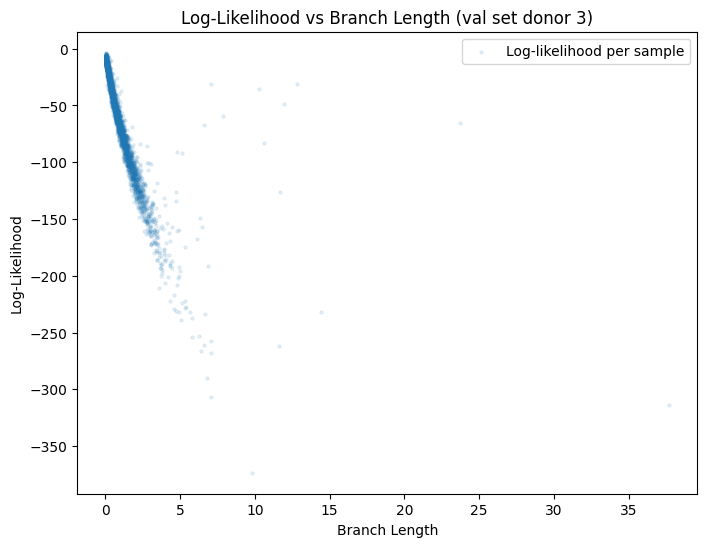

In [20]:
# plot the binned likelihoods according to the branch length
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(.15).astype(float)
binned_df = df.groupby("bl_bin").mean()

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(binned_df.branch_length, binned_df.ll, label="Binned log-likelihood", s=10)
ax.scatter(df.branch_length, df.ll, alpha=0.1, label="Log-likelihood per sample", s=5)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Log-Likelihood vs Branch Length (val set donor 3)")
ax.legend()
plt.show()

### Validate sampling from the codon model

In [ ]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/nt/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

# load the generator from the peint model
generator = PEINTGenerator.from_peint(module.net).to(device)

In [12]:
# for each transition in the test set, sample a child sequence using the model and compute its hamming distance + codon usage compared to the true child sequence
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
sim_child_hv_seqs, sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 20

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    [x_src, x_tgt, y_src, y_tgt, ts, chain_ids, x_sizes, y_sizes] = batch

    # get heavy chain lengths
    x_lens = (x_sizes[:,0]-1)*3
    y_lens = (y_sizes[:,0]-1)*3

    # decode the true child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x_src[i].cpu().numpy()) for i in range(x_src.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y_tgt[i].cpu().numpy()) for i in range(y_tgt.size(0))]
    true_hv_pa_seqs, true_lt_pa_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(true_parent_seqs, x_lens)])
    true_hv_ch_seqs, true_lt_ch_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(true_child_seqs, y_lens)])
    assert all([len(tc) == (ys.sum().item()) * 3 for tc, ys in zip(true_child_seqs, y_sizes)])

    # sample a child sequence using the model
    y_sizes[:,1] += 1
    y_decoded = generator.dec_generate(ts=ts, xs=x_src, x_sizes=x_sizes, y_sizes=y_sizes, chain_ids=chain_ids)
    sim_child_seqs = [decode_sequence_from_toks(y_decoded[i].cpu().numpy()) for i in range(y_decoded.size(0))]
    sim_hv_seqs, sim_lt_seqs = zip(*[(seq[:hl], seq[hl:]) for seq, hl in zip(sim_child_seqs, y_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_child_seqs)])

    real_parent_hv_seqs.extend(true_hv_pa_seqs)
    real_parent_lt_seqs.extend(true_lt_pa_seqs)
    real_child_hv_seqs.extend(true_hv_ch_seqs)
    real_child_lt_seqs.extend(true_lt_ch_seqs)
    sim_child_hv_seqs.extend(sim_hv_seqs)
    sim_child_lt_seqs.extend(sim_lt_seqs)
    branch_lengths.extend(ts[:,0].cpu().numpy())

    n_batches -= 1
    if n_batches == 0:
        break

Inference:   1%|█▋                                                                                                                                                                                 | 19/1968 [01:37<2:46:45,  5.13s/it]


In [14]:
assert len(true_parent_seqs[0]) == len(true_hv_pa_seqs[0]) + len(true_lt_pa_seqs[0])
assert len(true_child_seqs[0]) == len(true_hv_ch_seqs[0]) + len(true_lt_ch_seqs[0])
assert len(sim_child_seqs[0]) == len(sim_hv_seqs[0]) + len(sim_lt_seqs[0])
assert len(true_parent_seqs[0]) == len(true_child_seqs[0]) == len(sim_child_seqs[0])

In [29]:
# translate the sequences to amino acid sequences
from Bio.Seq import Seq

def translate_sequence(dna_seq):
    seq_obj = Seq(dna_seq)
    return str(seq_obj.translate())

real_hv_parent_aa_seqs = [translate_sequence(seq) for seq in real_parent_hv_seqs]
real_lt_parent_aa_seqs = [translate_sequence(seq) for seq in real_parent_lt_seqs]
real_hv_aa_seqs = [translate_sequence(seq) for seq in real_child_hv_seqs]
sim_hv_aa_seqs = [translate_sequence(seq) for seq in sim_child_hv_seqs]
real_lt_aa_seqs = [translate_sequence(seq) for seq in real_child_lt_seqs]
sim_lt_aa_seqs = [translate_sequence(seq) for seq in sim_child_lt_seqs]

In [30]:
# calculate hamming distances between corresponding real and simulated sequences
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

hv_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_hv_aa_seqs, sim_hv_aa_seqs)]
lt_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_lt_aa_seqs, sim_lt_aa_seqs)]

hv_aa_hamming_dists_to_parent = [compute_hamming_distance(p, s) for p, s in zip(real_hv_parent_aa_seqs, sim_hv_aa_seqs)]
lt_aa_hamming_dists_to_parent = [compute_hamming_distance(p, s) for p, s in zip(real_lt_parent_aa_seqs, sim_lt_aa_seqs)]

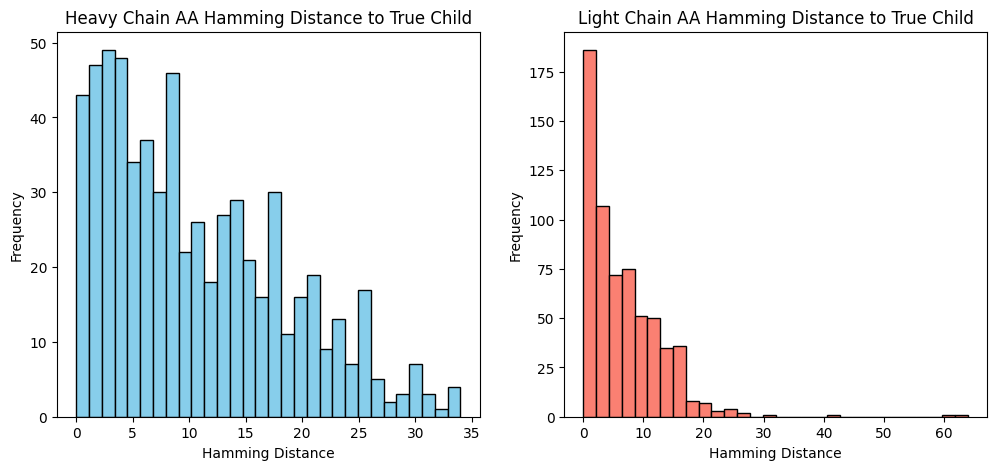

In [19]:
# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(hv_aa_hamming_dists, bins=30, color='skyblue', edgecolor='black')
ax[0].set_title('Heavy Chain AA Hamming Distance to True Child')
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency') 
ax[1].hist(lt_aa_hamming_dists, bins=30, color='salmon', edgecolor='black')
ax[1].set_title('Light Chain AA Hamming Distance to True Child')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')
plt.show()

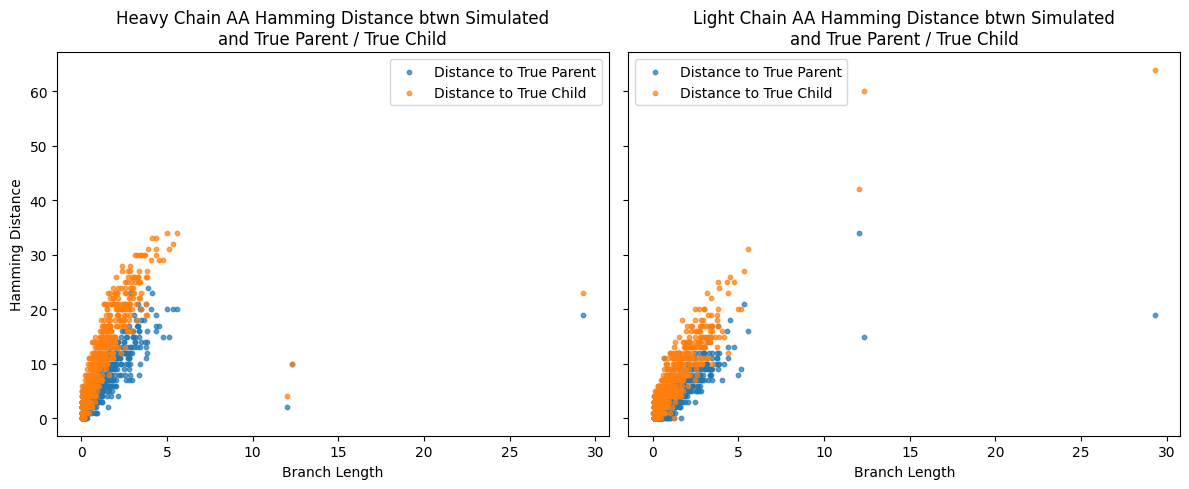

In [35]:
import numpy as np

# plot branch length vs hamming distance to parent and to true child (heavy & light)

bl = np.array(branch_lengths)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Heavy chain: distance to parent (blue) and to true child (orange)
ax[0].scatter(bl, hv_aa_hamming_dists_to_parent, color='C0', s=10, alpha=0.7, label='Distance to True Parent')
ax[0].scatter(bl, hv_aa_hamming_dists, color='C1', s=10, alpha=0.7, label='Distance to True Child')
ax[0].set_title('Heavy Chain AA Hamming Distance btwn Simulated\nand True Parent / True Child')
ax[0].set_xlabel('Branch Length')
ax[0].set_ylabel('Hamming Distance')
ax[0].legend()

# Light chain: distance to parent (blue) and to true child (orange)
ax[1].scatter(bl, lt_aa_hamming_dists_to_parent, color='C0', s=10, alpha=0.7, label='Distance to True Parent')
ax[1].scatter(bl, lt_aa_hamming_dists, color='C1', s=10, alpha=0.7, label='Distance to True Child')
ax[1].set_title('Light Chain AA Hamming Distance btwn Simulated\nand True Parent / True Child')
ax[1].set_xlabel('Branch Length')
ax[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# calculate codon usage frequencies for each set of sequences
from Bio.Seq import Seq
from collections import OrderedDict, Counter
from evo.sequence import HUMAN_CODON_USAGE

def compute_codon_usage_counts(sequence: str) -> dict:
    codon_counts = Counter()
    for i in range(0, len(sequence) - 2, 3):
        codon = sequence[i:i+3]
        if codon in HUMAN_CODON_USAGE:
            codon_counts[codon] += 1
    return codon_counts

def compute_aa_usage_counts(sequence: str) -> dict:
    aa_counts = Counter()
    for aa in sequence:
        aa_counts[aa] += 1
    return aa_counts

In [21]:
real_hv_codon_counts = [compute_codon_usage_counts(seq) for seq in real_child_hv_seqs]
real_hv_codon_counts = sum(real_hv_codon_counts, Counter())

sim_hv_codon_counts = [compute_codon_usage_counts(seq) for seq in sim_child_hv_seqs]
sim_hv_codon_counts = sum(sim_hv_codon_counts, Counter())

real_lt_codon_counts = [compute_codon_usage_counts(seq) for seq in real_child_lt_seqs]
real_lt_codon_counts = sum(real_lt_codon_counts, Counter())

sim_lt_codon_counts = [compute_codon_usage_counts(seq) for seq in sim_child_lt_seqs]
sim_lt_codon_counts = sum(sim_lt_codon_counts, Counter())

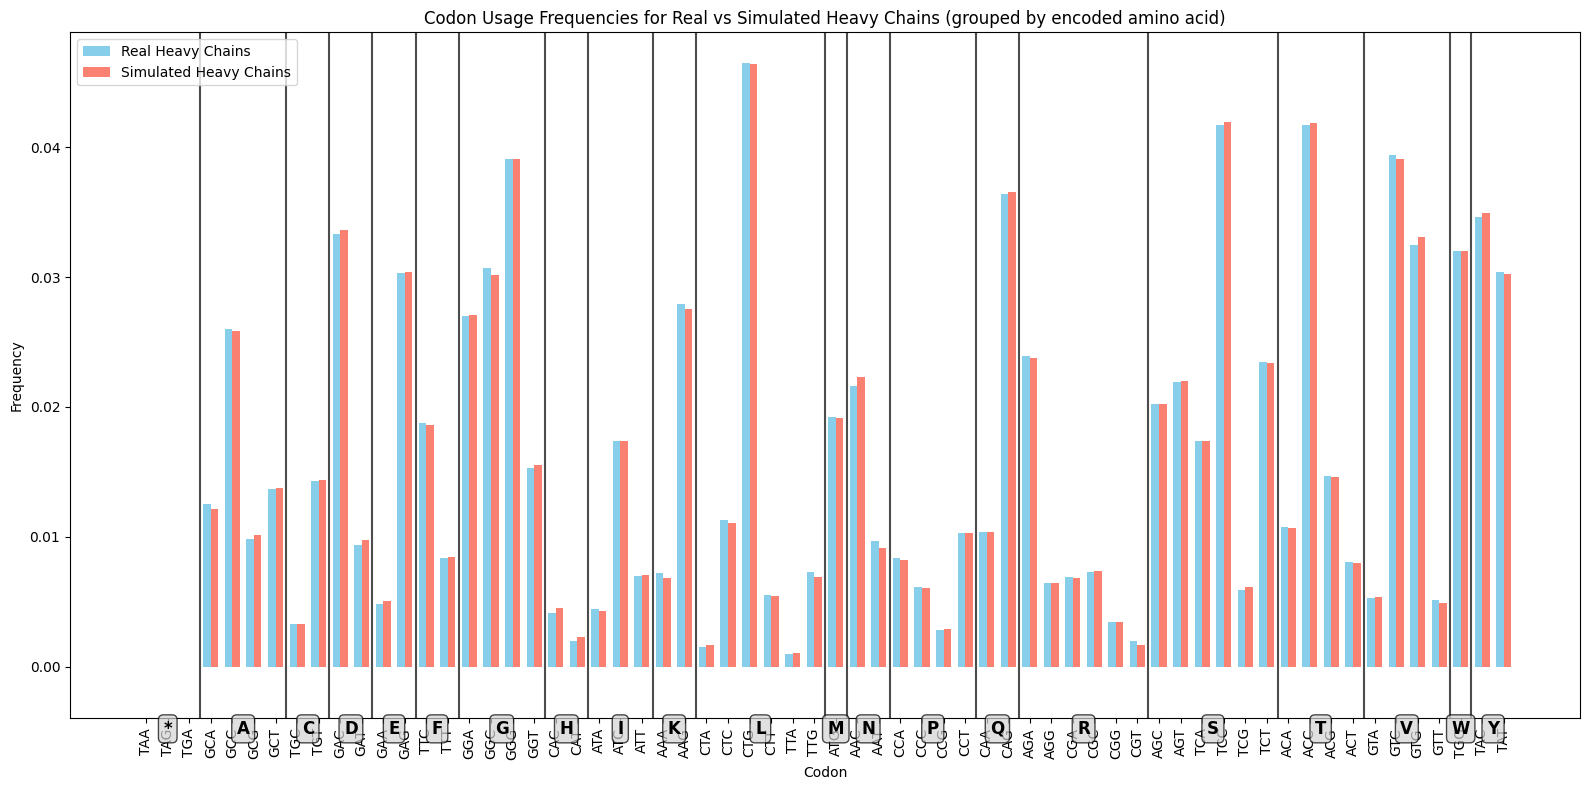

In [22]:
# plot the codon usage frequences for heavy chain
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])

# Create proper codon to amino acid mapping
codon_to_aa = {}
for c in codons:
    try:
        aa = str(Seq(c).translate())
        codon_to_aa[c] = aa
    except:
        continue  # Skip invalid codons

# Filter codons to only those with valid translations
valid_codons = [c for c in codons if c in codon_to_aa]

# **KEY FIX**: Sort codons by amino acid first, then by codon
# This ensures all codons for the same AA are grouped together
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# Now get frequencies for the properly sorted codons
heavy_real_freqs = [real_hv_codon_counts.get(codon, 0) / sum(real_hv_codon_counts.values()) for codon in valid_codons]
heavy_sim_freqs = [sim_hv_codon_counts.get(codon, 0) / sum(sim_hv_codon_counts.values()) for codon in valid_codons]

# Build ordered groups by amino acid
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Prepare plot
x = np.arange(len(valid_codons))
fig, ax = plt.subplots(figsize=(16, 8))
width = 0.35  # width of the bars
ax.bar(x - width/2, heavy_real_freqs, width, label='Real Heavy Chains', color='skyblue')
ax.bar(x + width/2, heavy_sim_freqs, width, label='Simulated Heavy Chains', color='salmon')

# Set ticks and codon labels
ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Real vs Simulated Heavy Chains (grouped by encoded amino acid)')

# Draw group separators and add amino-acid labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices)
    right = max(indices)
    center = (left + right) / 2.0
    
    # Vertical separator at the right edge of the group (except after last group)
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Place amino-acid labels below the x-axis at group centers
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

# Improve layout
ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

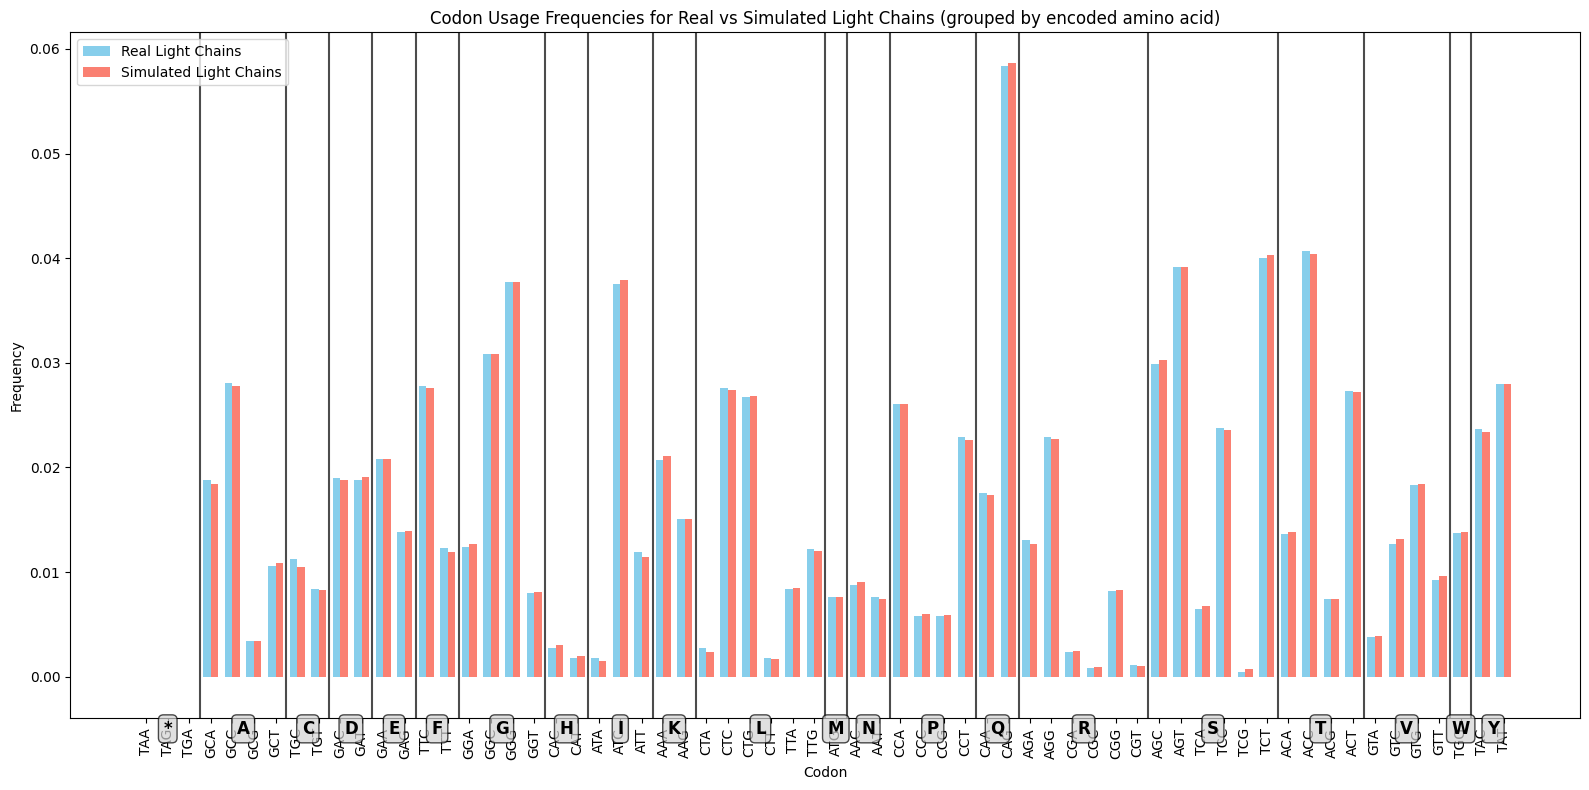

In [23]:
# plot the codon usage frequences for light chain
codons = sorted([c for c in HUMAN_CODON_USAGE.keys() if len(c) == 3 and set(c).issubset({'A', 'T', 'G', 'C'})])

# Create proper codon to amino acid mapping
codon_to_aa = {}
for c in codons:
    try:
        aa = str(Seq(c).translate())
        codon_to_aa[c] = aa
    except:
        continue  # Skip invalid codons

# Filter codons to only those with valid translations
valid_codons = [c for c in codons if c in codon_to_aa]

# **KEY FIX**: Sort codons by amino acid first, then by codon
# This ensures all codons for the same AA are grouped together
valid_codons = sorted(valid_codons, key=lambda c: (codon_to_aa[c], c))

# Now get frequencies for the properly sorted codons
light_real_freqs = [real_lt_codon_counts.get(codon, 0) / sum(real_lt_codon_counts.values()) for codon in valid_codons]
light_sim_freqs = [sim_lt_codon_counts.get(codon, 0) / sum(sim_lt_codon_counts.values()) for codon in valid_codons]

# Build ordered groups by amino acid
aa_groups = OrderedDict()
for i, c in enumerate(valid_codons):
    aa = codon_to_aa[c]
    aa_groups.setdefault(aa, []).append((i, c))

# Prepare plot
x = np.arange(len(valid_codons))
fig, ax = plt.subplots(figsize=(16, 8))
width = 0.35  # width of the bars
ax.bar(x - width/2, light_real_freqs, width, label='Real Light Chains', color='skyblue')
ax.bar(x + width/2, light_sim_freqs, width, label='Simulated Light Chains', color='salmon')

# Set ticks and codon labels
ax.set_xticks(x)
ax.set_xticklabels(valid_codons, rotation=90)
ax.set_xlabel('Codon')
ax.set_ylabel('Frequency')
ax.set_title('Codon Usage Frequencies for Real vs Simulated Light Chains (grouped by encoded amino acid)')

# Draw group separators and add amino-acid labels
for aa, items in aa_groups.items():
    indices = [idx for idx, _ in items]
    left = min(indices)
    right = max(indices)
    center = (left + right) / 2.0
    
    # Vertical separator at the right edge of the group (except after last group)
    if right < len(valid_codons) - 1:
        ax.axvline(right + 0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    # Place amino-acid labels below the x-axis at group centers
    ax.text(center, -0.002, aa, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

# Improve layout
ax.set_ylim(bottom=-0.004)
plt.subplots_adjust(bottom=0.15)
ax.legend()
plt.tight_layout()
plt.show()

## Calculate log likelihoods on Koenig DMS data
### Explore adding null mutation correction with Thrifty

In [5]:
from Bio.Seq import Seq
from typing import List, Dict

from netam import pretrained
from netam.framework import Crepe
from netam.models import IndepRSCNNModel
from netam.molevol import neutral_codon_probs_of_seq
from evo.antibody import KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ
from netam.sequences import CODONS, CODON_TO_INDEX, AMBIGUOUS_CODON_IDX

In [6]:
# load the pre-trained null mutation rate model Thrifty
crepe = pretrained.load("ThriftyHumV0.2-45")
multihit_model = pretrained.load_multihit("ThriftyHumV0.2-59-hc-tangshm", device="cpu")
print(crepe)
print(multihit_model)

Loading model ThriftyHumV0.2-45
Using cached models: /accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/netam/_pretrained/thrifty-0.2.0.zip
Loading multihit model ThriftyHumV0.2-59-hc-tangshm
HitClassModel()


In [7]:
# Infer ppl for the koenig binding dataset
df = pd.read_csv("data/flab/Koenig2017_g6_er.csv")
df = df[['heavy', 'light', 'fitness']]

heavy_wt = get_site_by_site_consensus(df, "heavy")
light_wt = get_site_by_site_consensus(df, "light")
print(len(heavy_wt), len(light_wt), len(heavy_wt) + len(light_wt))

df['heavy_mut'] = df['heavy'].apply(lambda x: get_mutant(x, heavy_wt))
df['light_mut'] = df['light'].apply(lambda x: get_mutant(x, light_wt))

df_heavy = df[df['heavy_mut'] != '']
df_light = df[df['light_mut'] != '']
df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
df_light.rename(columns={'light_mut': 'mut'}, inplace=True)
df_heavy.set_index('mut', inplace=True)
df_light.set_index('mut', inplace=True)

heavy_mut_codes = df_heavy.index.values.tolist()
light_mut_codes = df_light.index.values.tolist()

print(df_heavy.shape, df_light.shape)
print(len(df_heavy) + len(df_light))

120 108 228
(2261, 4) (2014, 4)
4275


/tmp/ipykernel_494618/1787751371.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy.rename(columns={'heavy_mut': 'mut'}, inplace=True)
/tmp/ipykernel_494618/1787751371.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light.rename(columns={'light_mut': 'mut'}, inplace=True)


In [8]:
codon_table = CodonVocab.GENETIC_CODE
assert Seq(KOENIG_IGH_CON_SEQ).translate() == heavy_wt
assert Seq(KOENIG_IGK_CON_SEQ).translate() == light_wt

In [100]:
# Compute neutral codon substitution probabilities for the wildtype sequences
nt_rates, csp_logits = crepe([KOENIG_IGH_CON_SEQ, KOENIG_IGK_CON_SEQ])
csps = torch.softmax(csp_logits, dim=-1)

heavy_nt_rates, heavy_csps = nt_rates[0], csps[0]
light_nt_rates, light_csps = nt_rates[1], csps[1]
heavy_mask = torch.zeros_like(heavy_nt_rates, dtype=torch.bool)
light_mask = torch.zeros_like(light_nt_rates, dtype=torch.bool)
heavy_mask[:len(KOENIG_IGH_CON_SEQ)] = True
light_mask[:len(KOENIG_IGK_CON_SEQ)] = True

heavy_branch_length = 1.0
light_branch_length = 1.0

hv_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGH_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGH_CON_SEQ), 3)]
lt_wt_codon_idxs = [CODON_TO_INDEX[KOENIG_IGK_CON_SEQ[i:i+3]] for i in range(0, len(KOENIG_IGK_CON_SEQ), 3)]
hv_wt_codon_idxs = torch.tensor(hv_wt_codon_idxs, dtype=torch.long)
lt_wt_codon_idxs = torch.tensor(lt_wt_codon_idxs, dtype=torch.long)

heavy_codon_probs = neutral_codon_probs_of_seq(
    KOENIG_IGH_CON_SEQ, heavy_mask, heavy_nt_rates,
    heavy_csps, heavy_branch_length, multihit_model=multihit_model,
)
light_codon_probs = neutral_codon_probs_of_seq(
    KOENIG_IGK_CON_SEQ, light_mask, light_nt_rates,
    light_csps, light_branch_length, multihit_model=multihit_model,
)

assert len(hv_wt_codon_idxs) == len(heavy_codon_probs)
assert len(lt_wt_codon_idxs) == len(light_codon_probs)

In [101]:
def replace_with_codons(wt_nt_sequence: str, mut: str, offset: int = 0):
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in codon_table.items() if v == new_aa]
    nt_pos = (pos - offset) * 3
    new_sequences = []
    for codon in codons:
        new_seq = wt_nt_sequence[:nt_pos] + codon + wt_nt_sequence[nt_pos+3:]
        new_sequences.append(new_seq)
    return new_sequences

def get_codons_from_mut(mut: str) -> List[str]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = [k for k,v in codon_table.items() if v == new_aa]
    return codons

def compute_edit_distance_of_codon_mut(wt_nucleotide_seq: str, aa_mut: str) -> List[int]:
    wt_aa, pos, new_aa = aa_mut[:1], int(aa_mut[1:-1]), aa_mut[-1:]
    codons = get_codons_from_mut(aa_mut)
    nt_pos = pos * 3
    wt_codon = wt_nucleotide_seq[nt_pos:nt_pos+3]
    edit_distances = [sum(c1 != c2 for c1, c2 in zip(wt_codon, codon)) for codon in codons]
    return edit_distances

def compute_codon_probs(codon_idxs: torch.Tensor, codon_probs: torch.Tensor) -> float:
    # codon_idxs is a 1d tensor of codon indices (seq_len,) and codon_probs is a 2d tensor of shape (seq_len, num_codons)
    return codon_probs[torch.arange(codon_idxs.size(0)), codon_idxs].sum().item()

def compute_mutant_codon_probs(wt_codon_idxs: torch.Tensor, mut: str, codon_probs: torch.Tensor) -> List[float]:
    wt_aa, pos, new_aa = mut[:1], int(mut[1:-1]), mut[-1:]
    codons = get_codons_from_mut(mut)
    mt_codon_idxs = [CODON_TO_INDEX[codon] for codon in codons]
    mt_codon_seq_probs = []
    for mt_codon_idx in mt_codon_idxs:
        mutant_codon_idxs = wt_codon_idxs.clone()
        mutant_codon_idxs[pos] = mt_codon_idx
        mutant_codon_prob = compute_codon_probs(mutant_codon_idxs, codon_probs)
        mt_codon_seq_probs.append(mutant_codon_prob)
    return mt_codon_seq_probs

In [102]:
# for each possible single amino acid change in the heavy chain, compute the log probability of that change under the heavy_codon_probs
shm_hv_probs_dict, shm_lt_probs_dict = defaultdict(list), defaultdict(list)
shm_hv_ed_dict, shm_lt_ed_dict = defaultdict(list), defaultdict(list)

for i, row in tqdm(df_heavy.iterrows(), desc="Heavy Chain SHM LLs"):
    mut_code = row.name
    wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
    mt_codon_seq_probs = compute_mutant_codon_probs(hv_wt_codon_idxs, mut_code, heavy_codon_probs)
    shm_hv_probs_dict[mut_code] = mt_codon_seq_probs
    shm_hv_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGH_CON_SEQ, mut_code)

for i, row in tqdm(df_light.iterrows(), desc="Light Chain SHM LLs"):
    mut_code = row.name
    wt_aa, pos, new_aa = mut_code[:1], int(mut_code[1:-1]), mut_code[-1:]
    mt_codon_seq_probs = compute_mutant_codon_probs(lt_wt_codon_idxs, mut_code, light_codon_probs)
    shm_lt_probs_dict[mut_code] = mt_codon_seq_probs
    shm_lt_ed_dict[mut_code] = compute_edit_distance_of_codon_mut(KOENIG_IGK_CON_SEQ, mut_code)

# logsumexp over lls and take min over edit distances
shm_hv_ll_final_dict = {k: np.log(np.logaddexp.reduce(v)) for k, v in shm_hv_probs_dict.items()}
shm_lt_ll_final_dict = {k: np.log(np.logaddexp.reduce(v)) for k, v in shm_lt_probs_dict.items()}
shm_hv_ed_final_dict = {k: min(v) for k, v in shm_hv_ed_dict.items()}
shm_lt_ed_final_dict = {k: min(v) for k, v in shm_lt_ed_dict.items()}

# add the computed log probabilities back to the dataframes
for mut_code in df_heavy.index:
    df_heavy.loc[mut_code, 'shm_log_prob'] = shm_hv_ll_final_dict[mut_code]
    df_heavy.loc[mut_code, 'shm_edit_distance'] = shm_hv_ed_final_dict[mut_code]

for mut_code in df_light.index:
    df_light.loc[mut_code, 'shm_log_prob'] = shm_lt_ll_final_dict[mut_code]
    df_light.loc[mut_code, 'shm_edit_distance'] = shm_lt_ed_final_dict[mut_code]

Heavy Chain SHM LLs: 2261it [00:00, 6177.76it/s]
Light Chain SHM LLs: 2014it [00:00, 6150.01it/s]


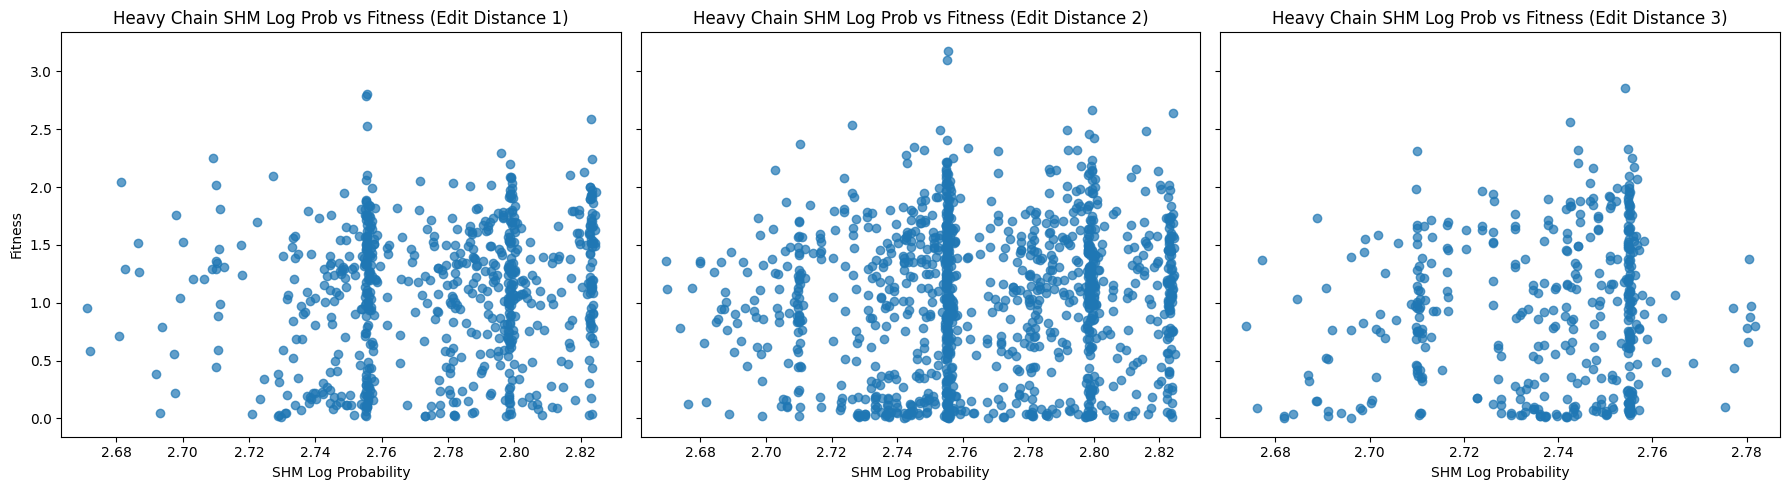

In [103]:
# scatter plot of the log probabilities vs the fitness values for the heavy chain
# make three subplots: one for each value of edit distance (1, 2, 3)
fig, ax = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, ed in enumerate([1, 2, 3]):
    subset = df_heavy[df_heavy['shm_edit_distance'] == ed]
    ax[i].scatter(subset['shm_log_prob'], subset['fitness'], alpha=0.7)
    ax[i].set_title(f'Heavy Chain SHM Log Prob vs Fitness (Edit Distance {ed})')
    ax[i].set_xlabel('SHM Log Probability')
    if i == 0:
        ax[i].set_ylabel('Fitness')
plt.tight_layout()
plt.show()

In [ ]:
hv_transitions = []
lt_transitions = []
hv_muts = []
lt_muts = []

for i, row in tqdm(df_heavy.iterrows()):
    hv_mut = row.name
    hv_nt_targets = replace_with_codons(KOENIG_IGH_CON_SEQ, hv_mut, offset=0)
    hv_muts.extend([hv_mut] * len(hv_nt_targets))
    min_ed = shm_hv_ed_final_dict[hv_mut]
    # t = 5.5 if min_ed == 1 else (6.5 if min_ed == 2 else 7.5)
    t = 7.5
    hv_transitions.extend([f"{KOENIG_IGH_CON_SEQ}.{KOENIG_IGK_CON_SEQ} {hv_mt}.{KOENIG_IGK_CON_SEQ} {t}" for hv_mt in hv_nt_targets])

for i, row in tqdm(df_light.iterrows()):
    lt_mut = row.name
    lt_nt_targets = replace_with_codons(KOENIG_IGK_CON_SEQ, lt_mut, offset=0)
    lt_muts.extend([lt_mut] * len(lt_nt_targets))
    min_ed = shm_lt_ed_final_dict[lt_mut]
    # t = 5.5 if min_ed == 1 else (6.5 if min_ed == 2 else 7.5)
    t = 7.5
    lt_transitions.extend([f"{KOENIG_IGH_CON_SEQ}.{KOENIG_IGK_CON_SEQ} {KOENIG_IGH_CON_SEQ}.{lt_mt} {t}" for lt_mt in lt_nt_targets])

hv_dataloader = dataloader_from_transitions(hv_transitions, batch_size=32, permute_chains=False)
hv_lls, _, hv_ppl = infer_log_likelihoods(hv_dataloader, module, n_batches=-1)

lt_dataloader = dataloader_from_transitions(lt_transitions, batch_size=32, permute_chains=False)
lt_lls, _, lt_ppl = infer_log_likelihoods(lt_dataloader, module, n_batches=-1)

2261it [00:00, 24103.23it/s]
2014it [00:00, 26561.67it/s]
Inference: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [00:21<00:00,  8.90it/s]


In [111]:
# map the heavy and light chain log likelihoods and perplexities to the mutations in a dictionary
hv_ll_dict, lt_ll_dict = defaultdict(list), defaultdict(list)

for hv_mut, hv_ll in zip(hv_muts, hv_lls):
    hv_ll_dict[hv_mut].append(hv_ll)

for lt_mut, lt_ll in zip(lt_muts, lt_lls):
    lt_ll_dict[lt_mut].append(lt_ll)

In [112]:
from scipy.special import logsumexp

edf = 0

for mut, mut_hv_lls in hv_ll_dict.items():
    mut_hv_lls = np.array(mut_hv_lls)
    hv_shm_lls = np.log(np.array(shm_hv_probs_dict[mut]))
    hv_edit_dists = edf * np.array(shm_hv_ed_dict[mut])
    assert len(mut_hv_lls) == len(hv_shm_lls)
    if len(mut_hv_lls) == 0:
        continue
    hv_ll = logsumexp(mut_hv_lls + hv_edit_dists)
    hv_corrected_ll = logsumexp(mut_hv_lls - hv_shm_lls + hv_edit_dists)
    hv_ppl = np.exp(-hv_ll / len(heavy_wt))
    hv_corrected_ppl = np.exp(-hv_corrected_ll / len(heavy_wt))
    df_heavy.loc[mut, 'll'] = hv_ll
    df_heavy.loc[mut, 'ppl'] = hv_ppl
    df_heavy.loc[mut, 'corrected_ll'] = hv_corrected_ll
    df_heavy.loc[mut, 'corrected_ppl'] = hv_corrected_ppl

for mut, mut_lt_lls in lt_ll_dict.items():
    mut_lt_lls = np.array(mut_lt_lls)
    lt_shm_lls = np.array(shm_lt_probs_dict[mut])
    lt_edit_dists = np.array(shm_lt_ed_dict[mut])
    assert len(mut_lt_lls) == len(lt_shm_lls)
    if len(mut_lt_lls) == 0:
        continue
    lt_ll = logsumexp(mut_lt_lls + lt_edit_dists)
    lt_corrected_ll = logsumexp(mut_lt_lls - lt_shm_lls + lt_edit_dists)
    lt_ppl = np.exp(-lt_ll / len(light_wt))
    lt_corrected_ppl = edf * np.exp(-lt_corrected_ll / len(light_wt))
    df_light.loc[mut, 'll'] = lt_ll
    df_light.loc[mut, 'ppl'] = lt_ppl
    df_light.loc[mut, 'corrected_ll'] = lt_corrected_ll
    df_light.loc[mut, 'corrected_ppl'] = lt_corrected_ppl

In [116]:
# for each number of edits (1, 2, 3), divide by the mean log likelihood of the mutations with that number of edits to get a corrected log likelihood
ll_to_correct = 'll'

for ed in [1, 2, 3]:
    hv_subset = df_heavy[df_heavy['shm_edit_distance'] == ed]
    lt_subset = df_light[df_light['shm_edit_distance'] == ed]
    hv_mean_ll = logsumexp(hv_subset[ll_to_correct].values) - np.log(len(hv_subset))
    lt_mean_ll = logsumexp(lt_subset[ll_to_correct].values) - np.log(len(lt_subset))
    df_heavy.loc[df_heavy['shm_edit_distance'] == ed, 'final_ll'] = df_heavy.loc[df_heavy['shm_edit_distance'] == ed, ll_to_correct] - hv_mean_ll
    df_light.loc[df_light['shm_edit_distance'] == ed, 'final_ll'] = df_light.loc[df_light['shm_edit_distance'] == ed, ll_to_correct] - lt_mean_ll

df_heavy['final_ppl'] = np.exp(-df_heavy['final_ll'] / len(heavy_wt))
df_light['final_ppl'] = np.exp(-df_light['final_ll'] / len(light_wt))

/tmp/ipykernel_494618/3540394032.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heavy['final_ppl'] = np.exp(-df_heavy['final_ll'] / len(heavy_wt))
/tmp/ipykernel_494618/3540394032.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_light['final_ppl'] = np.exp(-df_light['final_ll'] / len(light_wt))


In [117]:
# ppl_column = 'corrected_ppl'
ppl_column = 'final_ppl'
# ppl_column = 'ppl'

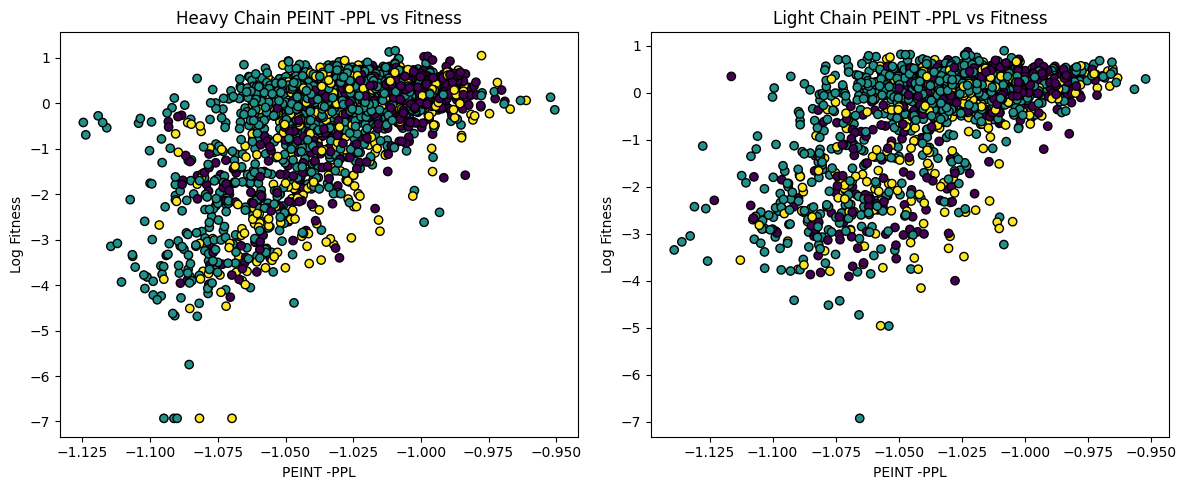

In [118]:
# plot ll vs fitness for heavy and light chains, colored by edit distance
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(-df_heavy[ppl_column], np.log(df_heavy['fitness']), c=df_heavy['shm_edit_distance'], edgecolor='black')
ax[0].set_title('Heavy Chain PEINT -PPL vs Fitness')
ax[0].set_xlabel('PEINT -PPL')
ax[0].set_ylabel('Log Fitness')
ax[1].scatter(-df_light[ppl_column], np.log(df_light['fitness']), c=df_light['shm_edit_distance'], edgecolor='black')
ax[1].set_title('Light Chain PEINT -PPL vs Fitness')
ax[1].set_xlabel('PEINT -PPL')
ax[1].set_ylabel('Log Fitness')
plt.tight_layout()
plt.show()

In [119]:
# calculate the pearson correlation between the ppl column and the log 'fitness' column for both heavy and light chains
import numpy as np
from scipy.stats import pearsonr

hv_corr, hv_pval = pearsonr(-df_heavy[ppl_column], np.log(df_heavy['fitness']))
lt_corr, lt_pval = pearsonr(-df_light[ppl_column], np.log(df_light['fitness']))

print(f"Heavy Chain - Pearson Correlation: {hv_corr:.4f}, p-value: {hv_pval:.4f}")
print(f"Light Chain - Pearson Correlation: {lt_corr:.4f}, p-value: {lt_pval:.4f}")

Heavy Chain - Pearson Correlation: 0.6009, p-value: 0.0000
Light Chain - Pearson Correlation: 0.5970, p-value: 0.0000
